# 2D Latent Space Visualization

Exploring autoencoder encodings with a 2D bottleneck (m=2) for intuition building.

Key questions:
- How do sparse features map to 2D latent space?
- Can we visually distinguish linear vs nonlinear encodings?
- How does depth and input dimension affect latent structure?

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from tqdm import tqdm
from typing import Tuple, Dict, List

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Autoencoder Architecture (from v0)

In [2]:
class Autoencoder(nn.Module):
    def __init__(self, n: int, m: int, l: int, activation=nn.ReLU):
        """
        Args:
            n: feature dimension (input/output width)
            m: bottleneck dimension
            l: number of layers on each side (encoder has l layers, decoder has l layers)
        """
        super().__init__()
        self.n = n
        self.m = m
        self.l = l
        
        # Build encoder: l layers of n->n, then n->m
        encoder_layers = []
        for i in range(l):
            encoder_layers.append(nn.Linear(n, n))
            encoder_layers.append(activation())
        encoder_layers.append(nn.Linear(n, m))  # final compression
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Build decoder: m->n, then l layers of n->n
        decoder_layers = []
        decoder_layers.append(nn.Linear(m, n))
        decoder_layers.append(activation())
        for i in range(l - 1):
            decoder_layers.append(nn.Linear(n, n))
            decoder_layers.append(activation())
        if l > 0:
            decoder_layers.append(nn.Linear(n, n))  # final output layer (no activation)
        self.decoder = nn.Sequential(*decoder_layers)
        
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

## Data Generation (from v0)

In [3]:
def generate_sparse_data(n_samples: int, n_features: int, sparsity: float = 0.1) -> torch.Tensor:
    """
    Generate sparse data where each feature is independently active with probability `sparsity`.
    Active features have random positive values.
    """
    mask = (torch.rand(n_samples, n_features) < sparsity).float()
    values = torch.rand(n_samples, n_features)
    return (mask * values).to(device)

## Training (from v0)

In [4]:
def train_autoencoder(
    model: Autoencoder,
    n_steps: int = 5000,
    batch_size: int = 256,
    sparsity: float = 0.1,
    lr: float = 1e-3,
    verbose: bool = True
) -> List[float]:
    """Train the autoencoder on sparse data."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    iterator = tqdm(range(n_steps)) if verbose else range(n_steps)
    for step in iterator:
        x = generate_sparse_data(batch_size, model.n, sparsity)
        
        optimizer.zero_grad()
        x_recon, z = model(x)
        loss = nn.functional.mse_loss(x_recon, x)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if verbose and step % 1000 == 0:
            iterator.set_postfix({'loss': f'{loss.item():.6f}'})
    
    return losses

## Basic Training with m=2

In [5]:
# Train a model with 2D latent space
n, m, l = 32, 2, 3
sparsity = 0.1

model = Autoencoder(n, m, l).to(device)
print(f"Model: n={n}, m={m}, l={l}")
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

losses = train_autoencoder(model, n_steps=5000, sparsity=sparsity)

Model: n=32, m=2, l=3
Parameters: 6498


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s, loss=0.050510]

  3%|▎         | 163/5000 [00:00<00:02, 1628.88it/s, loss=0.050510]

  8%|▊         | 382/5000 [00:00<00:02, 1950.71it/s, loss=0.050510]

...

 83%|████████▎ | 4171/5000 [00:02<00:00, 2075.44it/s, loss=0.021022]

 88%|████████▊ | 4379/5000 [00:02<00:00, 2069.61it/s, loss=0.021022]

 92%|█████████▏| 4588/5000 [00:02<00:00, 2075.59it/s, loss=0.021022]

 96%|█████████▌| 4799/5000 [00:02<00:00, 2084.75it/s, loss=0.021022]

100%|██████████| 5000/5000 [00:02<00:00, 2066.28it/s, loss=0.021022]

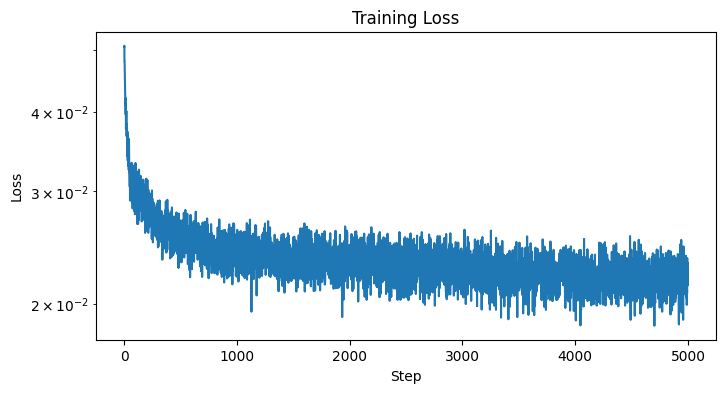

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.yscale('log')
plt.show()

## Latent Space Scatter Plots

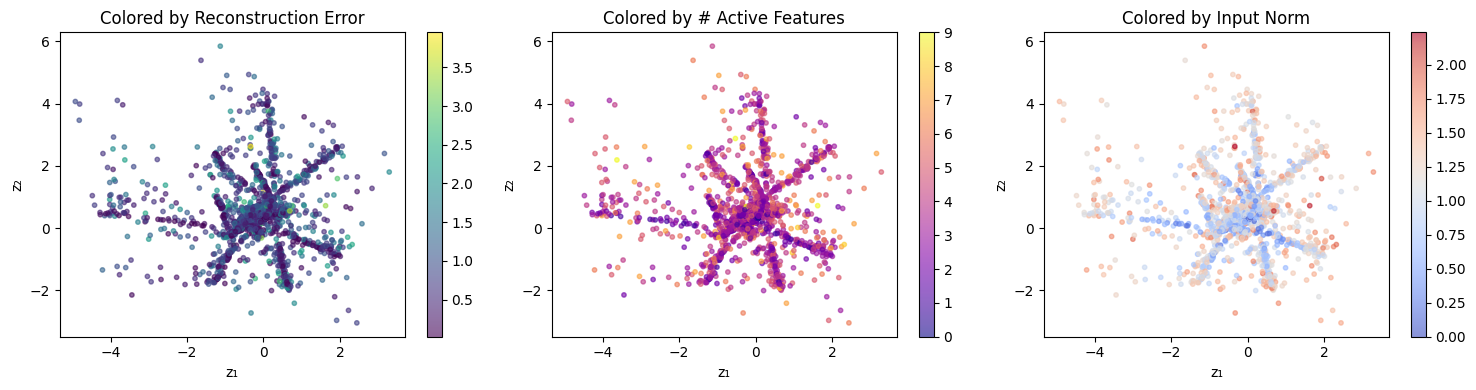

In [7]:
def plot_latent_scatter(model, n_samples=1000, sparsity=0.1, color_by='error'):
    """Plot latent encodings colored by various properties."""
    model.eval()
    with torch.no_grad():
        x = generate_sparse_data(n_samples, model.n, sparsity)
        x_recon, z = model(x)
        z = z.cpu().numpy()
        
        # Compute properties for coloring
        errors = ((x_recon - x) ** 2).sum(dim=1).cpu().numpy()
        sparsities = (x > 0).float().sum(dim=1).cpu().numpy()
        norms = x.norm(dim=1).cpu().numpy()
        
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Color by reconstruction error
    sc = axes[0].scatter(z[:, 0], z[:, 1], c=errors, cmap='viridis', alpha=0.6, s=10)
    axes[0].set_xlabel('z₁')
    axes[0].set_ylabel('z₂')
    axes[0].set_title('Colored by Reconstruction Error')
    plt.colorbar(sc, ax=axes[0])
    
    # Color by input sparsity (number of active features)
    sc = axes[1].scatter(z[:, 0], z[:, 1], c=sparsities, cmap='plasma', alpha=0.6, s=10)
    axes[1].set_xlabel('z₁')
    axes[1].set_ylabel('z₂')
    axes[1].set_title('Colored by # Active Features')
    plt.colorbar(sc, ax=axes[1])
    
    # Color by input norm
    sc = axes[2].scatter(z[:, 0], z[:, 1], c=norms, cmap='coolwarm', alpha=0.6, s=10)
    axes[2].set_xlabel('z₁')
    axes[2].set_ylabel('z₂')
    axes[2].set_title('Colored by Input Norm')
    plt.colorbar(sc, ax=axes[2])
    
    plt.tight_layout()
    plt.show()

plot_latent_scatter(model, n_samples=2000, sparsity=sparsity)

## Feature-wise Visualization

Where do samples with each specific feature active land in latent space?

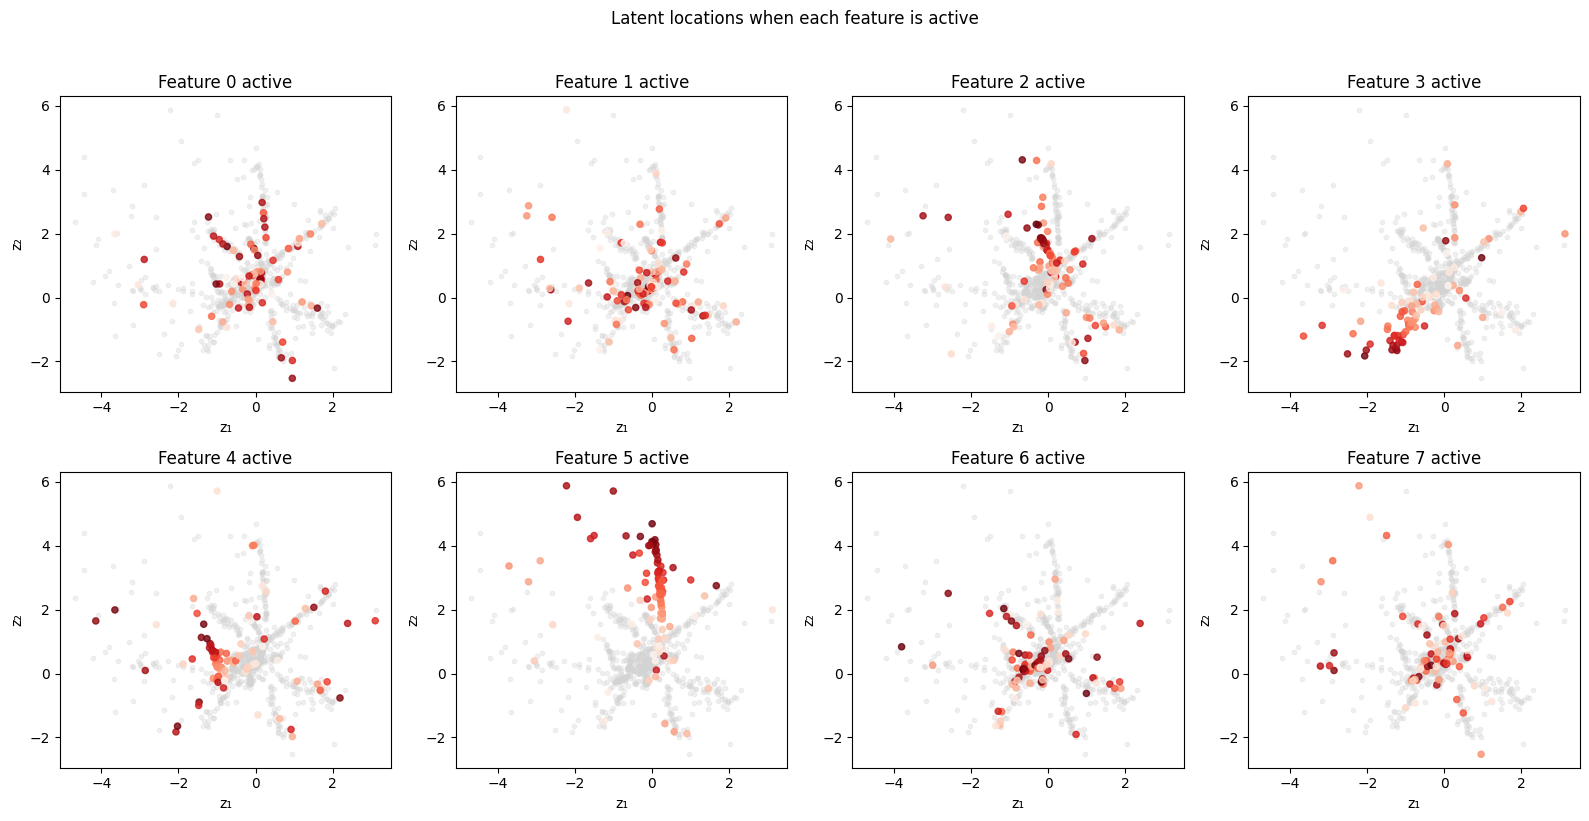

In [8]:
def plot_feature_locations(model, n_samples=500, sparsity=0.1, features_to_show=8):
    """Show where samples with specific features active land in latent space."""
    model.eval()
    
    with torch.no_grad():
        x = generate_sparse_data(n_samples, model.n, sparsity)
        z = model.encode(x).cpu().numpy()
        x_np = x.cpu().numpy()
    
    n_cols = 4
    n_rows = (features_to_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.flatten()
    
    for i in range(features_to_show):
        ax = axes[i]
        # Plot all points in gray
        ax.scatter(z[:, 0], z[:, 1], c='lightgray', alpha=0.3, s=10)
        
        # Highlight points where feature i is active
        active_mask = x_np[:, i] > 0
        if active_mask.sum() > 0:
            ax.scatter(z[active_mask, 0], z[active_mask, 1], 
                      c=x_np[active_mask, i], cmap='Reds', alpha=0.8, s=20,
                      vmin=0, vmax=1)
        
        ax.set_xlabel('z₁')
        ax.set_ylabel('z₂')
        ax.set_title(f'Feature {i} active')
    
    # Hide unused axes
    for i in range(features_to_show, len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Latent locations when each feature is active', y=1.02)
    plt.tight_layout()
    plt.show()

plot_feature_locations(model, n_samples=1000, sparsity=sparsity, features_to_show=8)

## Feature Magnitude Trajectories

**Key visualization for linear vs nonlinear distinction:**
- For each feature, vary its magnitude from 0 to 1 (all other features = 0)
- Linear encoding → straight line through origin
- Nonlinear encoding → curved path

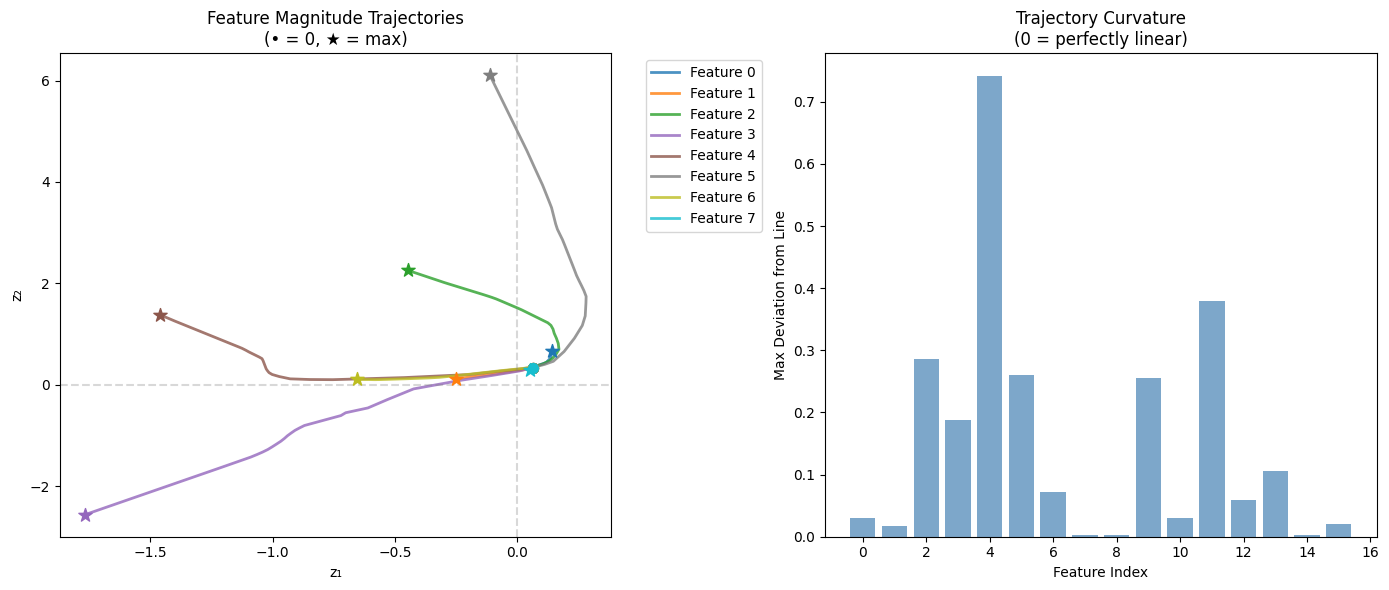

Average trajectory curvature: 0.1532
  (0 = linear encoding, higher = more nonlinear)


In [9]:
def plot_feature_trajectories(model, n_features_to_show=8, n_points=50, max_magnitude=1.5):
    """
    For each feature, trace its path through latent space as magnitude varies.
    Linear encoder: straight lines
    Nonlinear encoder: curves
    """
    model.eval()
    
    magnitudes = torch.linspace(0, max_magnitude, n_points).to(device)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    colors = plt.cm.tab10(np.linspace(0, 1, n_features_to_show))
    
    with torch.no_grad():
        for feat_idx in range(n_features_to_show):
            # Create inputs with only this feature active at various magnitudes
            x = torch.zeros(n_points, model.n, device=device)
            x[:, feat_idx] = magnitudes
            
            z = model.encode(x).cpu().numpy()
            
            # Plot trajectory
            axes[0].plot(z[:, 0], z[:, 1], '-', color=colors[feat_idx], 
                        linewidth=2, alpha=0.8, label=f'Feature {feat_idx}')
            # Mark start (magnitude=0) and end
            axes[0].scatter(z[0, 0], z[0, 1], color=colors[feat_idx], s=50, marker='o', zorder=5)
            axes[0].scatter(z[-1, 0], z[-1, 1], color=colors[feat_idx], s=100, marker='*', zorder=5)
    
    axes[0].set_xlabel('z₁')
    axes[0].set_ylabel('z₂')
    axes[0].set_title('Feature Magnitude Trajectories\n(• = 0, ★ = max)')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    
    # Right plot: Show curvature metric for each trajectory
    curvatures = []
    with torch.no_grad():
        for feat_idx in range(min(model.n, 16)):
            x = torch.zeros(n_points, model.n, device=device)
            x[:, feat_idx] = magnitudes
            z = model.encode(x).cpu().numpy()
            
            # Compute deviation from straight line
            # Fit line from start to end, measure max deviation
            start, end = z[0], z[-1]
            direction = end - start
            if np.linalg.norm(direction) > 1e-6:
                direction = direction / np.linalg.norm(direction)
                # Project each point onto line, compute perpendicular distance
                deviations = []
                for point in z:
                    vec = point - start
                    proj = np.dot(vec, direction) * direction
                    perp = vec - proj
                    deviations.append(np.linalg.norm(perp))
                curvatures.append(max(deviations))
            else:
                curvatures.append(0)
    
    axes[1].bar(range(len(curvatures)), curvatures, color='steelblue', alpha=0.7)
    axes[1].set_xlabel('Feature Index')
    axes[1].set_ylabel('Max Deviation from Line')
    axes[1].set_title('Trajectory Curvature\n(0 = perfectly linear)')
    
    plt.tight_layout()
    plt.show()
    
    avg_curvature = np.mean(curvatures)
    print(f"Average trajectory curvature: {avg_curvature:.4f}")
    print(f"  (0 = linear encoding, higher = more nonlinear)")

plot_feature_trajectories(model)

## Reconstruction Error Landscape

What does the decoder think about different regions of latent space?

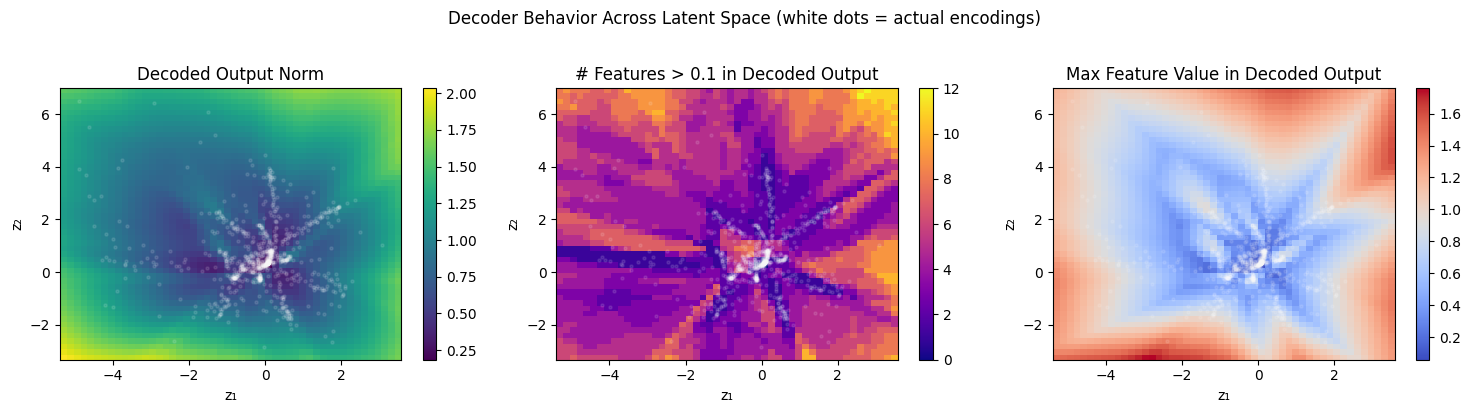

In [10]:
def plot_reconstruction_landscape(model, n_samples=1000, sparsity=0.1, grid_size=50):
    """Plot reconstruction error across the latent space."""
    model.eval()
    
    with torch.no_grad():
        # First, get the range of latent encodings
        x = generate_sparse_data(n_samples, model.n, sparsity)
        z_data = model.encode(x).cpu().numpy()
        
        z1_range = (z_data[:, 0].min() - 0.5, z_data[:, 0].max() + 0.5)
        z2_range = (z_data[:, 1].min() - 0.5, z_data[:, 1].max() + 0.5)
        
        # Create grid over latent space
        z1_grid = np.linspace(z1_range[0], z1_range[1], grid_size)
        z2_grid = np.linspace(z2_range[0], z2_range[1], grid_size)
        Z1, Z2 = np.meshgrid(z1_grid, z2_grid)
        
        # Decode each grid point and compute properties
        z_flat = torch.tensor(np.stack([Z1.flatten(), Z2.flatten()], axis=1), 
                              dtype=torch.float32, device=device)
        x_decoded = model.decode(z_flat)
        
        # Metrics for each decoded point
        output_norm = x_decoded.norm(dim=1).cpu().numpy().reshape(grid_size, grid_size)
        output_sparsity = (x_decoded > 0.1).float().sum(dim=1).cpu().numpy().reshape(grid_size, grid_size)
        output_max = x_decoded.max(dim=1).values.cpu().numpy().reshape(grid_size, grid_size)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Output norm
    im0 = axes[0].imshow(output_norm, extent=[z1_range[0], z1_range[1], z2_range[0], z2_range[1]],
                         origin='lower', cmap='viridis', aspect='auto')
    axes[0].scatter(z_data[:, 0], z_data[:, 1], c='white', alpha=0.1, s=5)
    axes[0].set_xlabel('z₁')
    axes[0].set_ylabel('z₂')
    axes[0].set_title('Decoded Output Norm')
    plt.colorbar(im0, ax=axes[0])
    
    # Output sparsity
    im1 = axes[1].imshow(output_sparsity, extent=[z1_range[0], z1_range[1], z2_range[0], z2_range[1]],
                         origin='lower', cmap='plasma', aspect='auto')
    axes[1].scatter(z_data[:, 0], z_data[:, 1], c='white', alpha=0.1, s=5)
    axes[1].set_xlabel('z₁')
    axes[1].set_ylabel('z₂')
    axes[1].set_title('# Features > 0.1 in Decoded Output')
    plt.colorbar(im1, ax=axes[1])
    
    # Max output value
    im2 = axes[2].imshow(output_max, extent=[z1_range[0], z1_range[1], z2_range[0], z2_range[1]],
                         origin='lower', cmap='coolwarm', aspect='auto')
    axes[2].scatter(z_data[:, 0], z_data[:, 1], c='white', alpha=0.1, s=5)
    axes[2].set_xlabel('z₁')
    axes[2].set_ylabel('z₂')
    axes[2].set_title('Max Feature Value in Decoded Output')
    plt.colorbar(im2, ax=axes[2])
    
    plt.suptitle('Decoder Behavior Across Latent Space (white dots = actual encodings)', y=1.02)
    plt.tight_layout()
    plt.show()

plot_reconstruction_landscape(model, sparsity=sparsity)

## Training Dynamics

How do latent representations evolve during training?

In [11]:
def train_with_snapshots(n, m, l, sparsity=0.1, n_steps=5000, snapshot_interval=500):
    """Train and save latent encodings periodically."""
    model = Autoencoder(n, m, l).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # Fixed test set for consistent comparisons
    x_test = generate_sparse_data(500, n, sparsity)
    
    snapshots = []
    losses = []
    
    for step in tqdm(range(n_steps)):
        x = generate_sparse_data(256, n, sparsity)
        
        optimizer.zero_grad()
        x_recon, z = model(x)
        loss = nn.functional.mse_loss(x_recon, x)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if step % snapshot_interval == 0 or step == n_steps - 1:
            model.eval()
            with torch.no_grad():
                z_test = model.encode(x_test).cpu().numpy()
            snapshots.append({'step': step, 'z': z_test, 'loss': loss.item()})
            model.train()
    
    return model, snapshots, losses, x_test

model_dyn, snapshots, losses_dyn, x_test = train_with_snapshots(n=32, m=2, l=3, sparsity=0.1)

  0%|          | 0/5000 [00:00<?, ?it/s]

  4%|▍         | 208/5000 [00:00<00:02, 2073.39it/s]

  8%|▊         | 416/5000 [00:00<00:02, 1744.92it/s]

 12%|█▎        | 625/5000 [00:00<00:02, 1885.30it/s]

 17%|█▋        | 832/5000 [00:00<00:02, 1952.58it/s]

...

 87%|████████▋ | 4351/5000 [00:02<00:00, 1863.06it/s]

 91%|█████████ | 4539/5000 [00:02<00:00, 1852.24it/s]

 95%|█████████▍| 4726/5000 [00:02<00:00, 1805.55it/s]

 98%|█████████▊| 4908/5000 [00:02<00:00, 1783.74it/s]

100%|██████████| 5000/5000 [00:02<00:00, 1927.76it/s]

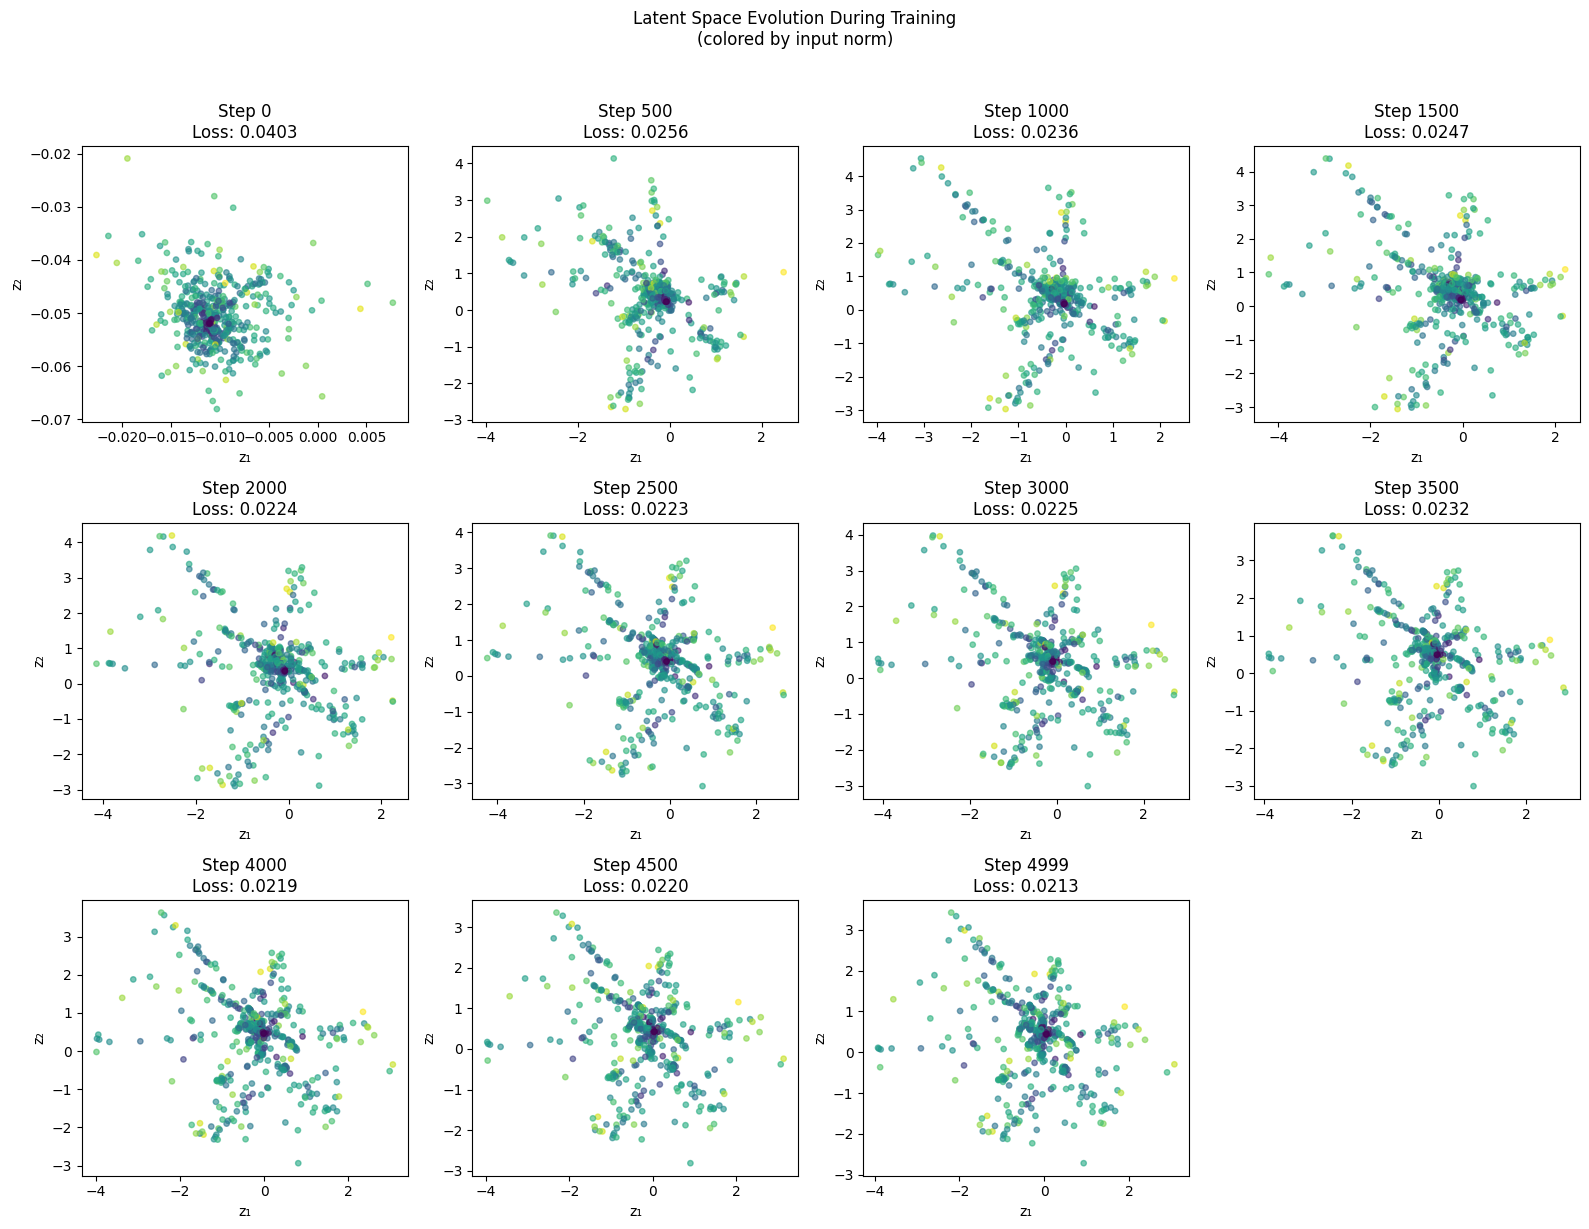

In [12]:
def plot_training_evolution(snapshots, x_test):
    """Plot how latent representations evolve during training."""
    n_snapshots = len(snapshots)
    n_cols = min(4, n_snapshots)
    n_rows = (n_snapshots + n_cols - 1) // n_cols
    
    # Color points by their input norm (consistent across snapshots)
    colors = x_test.norm(dim=1).cpu().numpy()
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = np.array(axes).flatten()
    
    for i, snap in enumerate(snapshots):
        ax = axes[i]
        z = snap['z']
        sc = ax.scatter(z[:, 0], z[:, 1], c=colors, cmap='viridis', alpha=0.6, s=15)
        ax.set_xlabel('z₁')
        ax.set_ylabel('z₂')
        ax.set_title(f"Step {snap['step']}\nLoss: {snap['loss']:.4f}")
    
    # Hide unused axes
    for i in range(len(snapshots), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Latent Space Evolution During Training\n(colored by input norm)', y=1.02)
    plt.tight_layout()
    plt.show()

plot_training_evolution(snapshots, x_test)

## Depth Comparison

How does encoder depth affect latent structure?

In [13]:
def compare_depths(n=32, m=2, depths=[1, 2, 3, 4], sparsity=0.1, n_steps=5000):
    """Train models with different depths and compare latent structures."""
    models = {}
    
    for l in depths:
        print(f"Training depth l={l}...")
        model = Autoencoder(n, m, l).to(device)
        train_autoencoder(model, n_steps=n_steps, sparsity=sparsity, verbose=False)
        models[l] = model
    
    return models

depth_models = compare_depths(n=32, m=2, depths=[1, 2, 3, 4], sparsity=0.1)

Training depth l=1...


Training depth l=2...


Training depth l=3...


Training depth l=4...


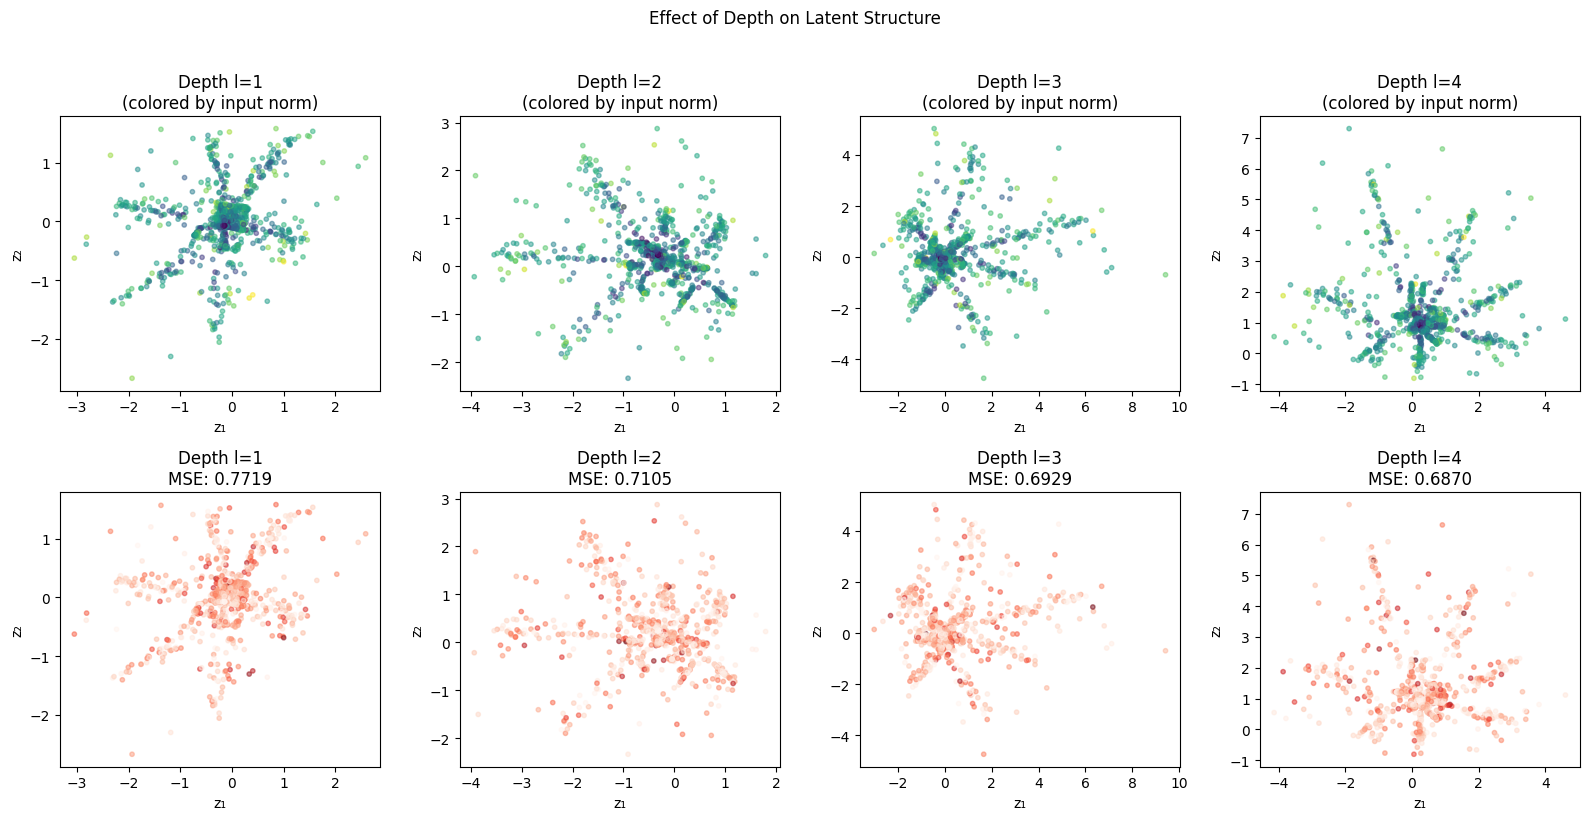

In [14]:
def plot_depth_comparison(models, n_samples=1000, sparsity=0.1):
    """Compare latent structures across depths."""
    n = list(models.values())[0].n
    x = generate_sparse_data(n_samples, n, sparsity)
    
    fig, axes = plt.subplots(2, len(models), figsize=(4*len(models), 8))
    
    colors_norm = x.norm(dim=1).cpu().numpy()
    
    for i, (l, model) in enumerate(sorted(models.items())):
        model.eval()
        with torch.no_grad():
            x_recon, z = model(x)
            z = z.cpu().numpy()
            errors = ((x_recon - x) ** 2).sum(dim=1).cpu().numpy()
        
        # Top row: colored by input norm
        sc = axes[0, i].scatter(z[:, 0], z[:, 1], c=colors_norm, cmap='viridis', alpha=0.5, s=10)
        axes[0, i].set_xlabel('z₁')
        axes[0, i].set_ylabel('z₂')
        axes[0, i].set_title(f'Depth l={l}\n(colored by input norm)')
        
        # Bottom row: colored by reconstruction error
        sc = axes[1, i].scatter(z[:, 0], z[:, 1], c=errors, cmap='Reds', alpha=0.5, s=10)
        axes[1, i].set_xlabel('z₁')
        axes[1, i].set_ylabel('z₂')
        axes[1, i].set_title(f'Depth l={l}\nMSE: {errors.mean():.4f}')
    
    plt.suptitle('Effect of Depth on Latent Structure', y=1.02)
    plt.tight_layout()
    plt.show()

plot_depth_comparison(depth_models, sparsity=0.1)

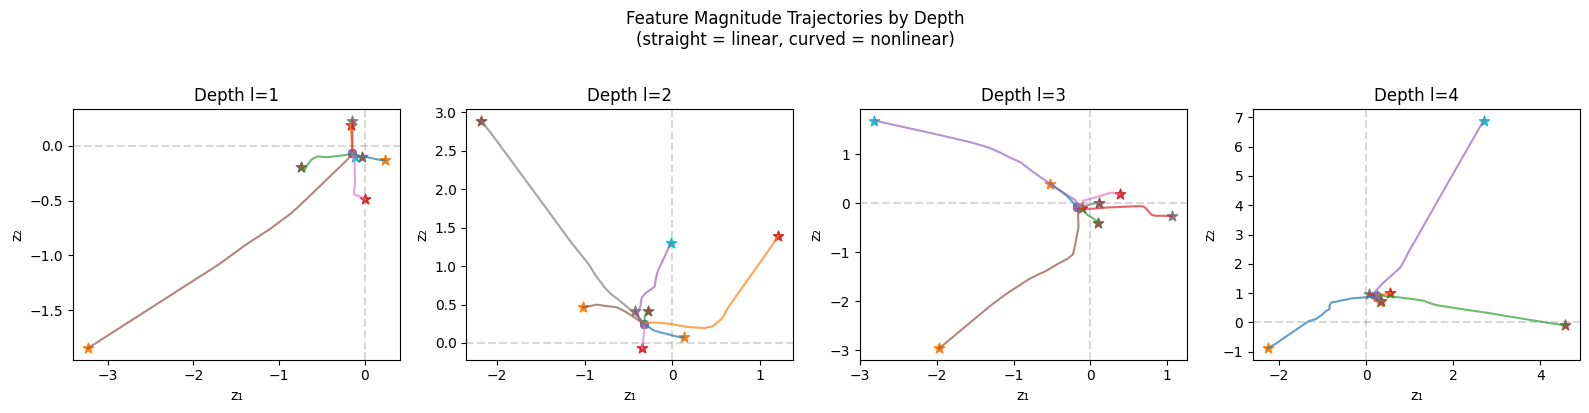

In [15]:
# Compare feature trajectories across depths
def compare_trajectories_by_depth(models, feature_idx=0, n_points=50, max_magnitude=1.5):
    """Compare how a single feature's trajectory varies with depth."""
    n = list(models.values())[0].n
    magnitudes = torch.linspace(0, max_magnitude, n_points).to(device)
    
    fig, axes = plt.subplots(1, len(models), figsize=(4*len(models), 4))
    
    for i, (l, model) in enumerate(sorted(models.items())):
        model.eval()
        ax = axes[i]
        
        with torch.no_grad():
            # Show multiple features
            for feat_idx in range(8):
                x = torch.zeros(n_points, n, device=device)
                x[:, feat_idx] = magnitudes
                z = model.encode(x).cpu().numpy()
                
                ax.plot(z[:, 0], z[:, 1], '-', alpha=0.7, linewidth=1.5)
                ax.scatter(z[0, 0], z[0, 1], s=30, marker='o')
                ax.scatter(z[-1, 0], z[-1, 1], s=60, marker='*')
        
        ax.set_xlabel('z₁')
        ax.set_ylabel('z₂')
        ax.set_title(f'Depth l={l}')
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    
    plt.suptitle('Feature Magnitude Trajectories by Depth\n(straight = linear, curved = nonlinear)', y=1.02)
    plt.tight_layout()
    plt.show()

compare_trajectories_by_depth(depth_models)

## Input Dimension Comparison

How does increasing input dimension (with fixed m=2) affect latent structure?

In [16]:
def compare_input_dims(n_values=[8, 16, 32, 64], m=2, l=3, sparsity=0.1, n_steps=5000):
    """Train models with different input dimensions."""
    models = {}
    
    for n in n_values:
        print(f"Training n={n}...")
        model = Autoencoder(n, m, l).to(device)
        train_autoencoder(model, n_steps=n_steps, sparsity=sparsity, verbose=False)
        models[n] = model
    
    return models

dim_models = compare_input_dims(n_values=[8, 16, 32, 64], m=2, l=3)

Training n=8...


Training n=16...


Training n=32...


Training n=64...


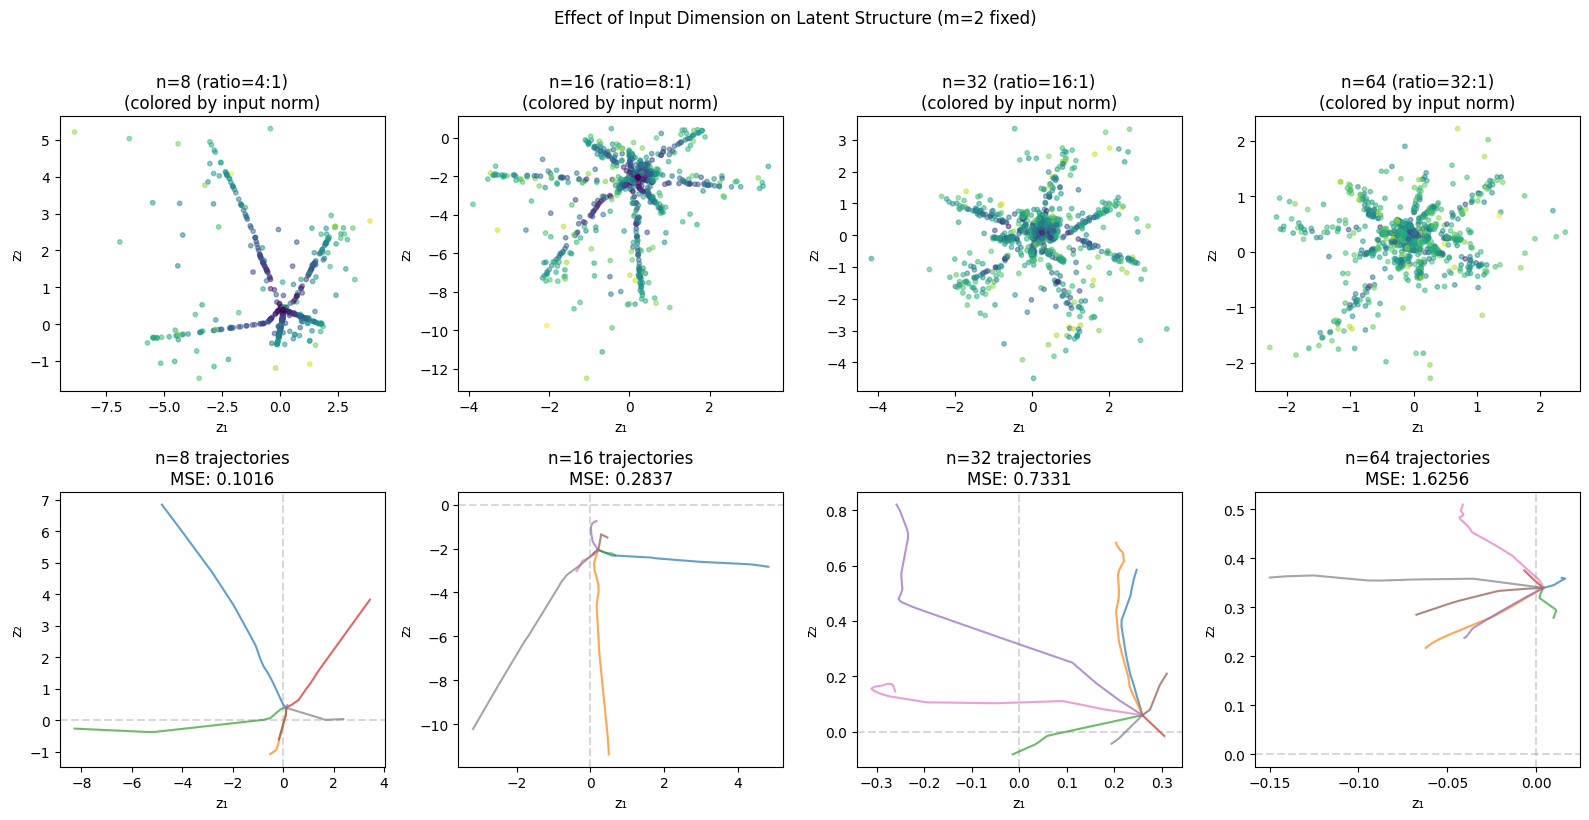

In [17]:
def plot_dim_comparison(models, n_samples=1000, sparsity=0.1):
    """Compare latent structures across input dimensions."""
    fig, axes = plt.subplots(2, len(models), figsize=(4*len(models), 8))
    
    for i, (n, model) in enumerate(sorted(models.items())):
        model.eval()
        x = generate_sparse_data(n_samples, n, sparsity)
        
        with torch.no_grad():
            x_recon, z = model(x)
            z = z.cpu().numpy()
            errors = ((x_recon - x) ** 2).sum(dim=1).cpu().numpy()
        
        colors_norm = x.norm(dim=1).cpu().numpy()
        
        # Top row: latent scatter
        sc = axes[0, i].scatter(z[:, 0], z[:, 1], c=colors_norm, cmap='viridis', alpha=0.5, s=10)
        axes[0, i].set_xlabel('z₁')
        axes[0, i].set_ylabel('z₂')
        axes[0, i].set_title(f'n={n} (ratio={n//2}:1)\n(colored by input norm)')
        
        # Bottom row: feature trajectories
        ax = axes[1, i]
        magnitudes = torch.linspace(0, 1.5, 30).to(device)
        
        with torch.no_grad():
            for feat_idx in range(min(8, n)):
                x_traj = torch.zeros(30, n, device=device)
                x_traj[:, feat_idx] = magnitudes
                z_traj = model.encode(x_traj).cpu().numpy()
                ax.plot(z_traj[:, 0], z_traj[:, 1], '-', alpha=0.7, linewidth=1.5)
        
        ax.set_xlabel('z₁')
        ax.set_ylabel('z₂')
        ax.set_title(f'n={n} trajectories\nMSE: {errors.mean():.4f}')
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    
    plt.suptitle('Effect of Input Dimension on Latent Structure (m=2 fixed)', y=1.02)
    plt.tight_layout()
    plt.show()

plot_dim_comparison(dim_models)

## Summary

Key observations to look for:

1. **Feature trajectories**: Straight lines indicate linear encoding; curves indicate nonlinear encoding
2. **Depth effect**: Deeper networks may develop more curved trajectories (more nonlinear)
3. **Compression ratio**: Higher n with fixed m=2 forces more "packing" into latent space
4. **Training dynamics**: Early training may be more linear, with nonlinearity emerging later

These visualizations help build intuition for when and why autoencoders learn nonlinear encodings.